Data Notebook

In [1]:
!pip install ipython==8.12.0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Setup: clone the repo. Default to Colab's local FS so anyone can run this end-to-end.
# Set USE_DRIVE = True if you want persistence across Colab sessions for yourself.

import os, sys

USE_DRIVE = True
GH_REPO   = "https://github.com/47v0/cs4782-final-project.git"

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/gdrive")
    PROJECT_ROOT = "/content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project"
else:
    PROJECT_ROOT = "/content/cs4782-final-project"

if not os.path.exists(PROJECT_ROOT):
    !git clone {GH_REPO} "{PROJECT_ROOT}"
else:
    !cd "{PROJECT_ROOT}" && git pull --ff-only

# Make `code/` importable (so notebooks can `from dataset import ...` later)
CODE_DIR = f"{PROJECT_ROOT}/code"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
!ls "{PROJECT_ROOT}"

Mounted at /content/gdrive
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 1), reused 9 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 81.02 KiB | 322.00 KiB/s, done.
From https://github.com/47v0/cs4782-final-project
   a888858..4007bc6  main       -> origin/main
Updating a888858..4007bc6
error: Your local changes to the following files would be overwritten by merge:
	code/dataset.py
	code/model.py
	code/train.py
Please commit your changes or stash them before you merge.
error: The following untracked working tree files would be overwritten by merge:
	code/notebooks/01_data.ipynb
	code/notebooks/03_training.ipynb
Please move or remove them before you merge.
Aborting
PROJECT_ROOT: /content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project
code  data  LICENSE  plan.txt  poster  README.md  report  results


In [4]:
# Unzip the bundled `all_six_datasets.zip` into data/all_six_datasets/ (idempotent)
DATA_DIR  = f"{PROJECT_ROOT}/data/all_six_datasets"
ZIP_PATH  = f"{PROJECT_ROOT}/data/all_six_datasets.zip"
ETTH1_CSV = f"{DATA_DIR}/ETT-small/ETTh1.csv"

if not os.path.exists(DATA_DIR):
    !unzip -q "{ZIP_PATH}" -d "{PROJECT_ROOT}/data"
else:
    print("already unzipped:", DATA_DIR)

print("ETTh1 csv:", ETTH1_CSV, "| exists:", os.path.exists(ETTH1_CSV))

ETTh1 csv: /content/gdrive/MyDrive/2025-2026/Sem 6/CS 4782/final_project/cs4782-final-project/data/all_six_datasets/ETT-small/ETTh1.csv | exists: True


In [5]:
import pandas as pd

df = pd.read_csv(ETTH1_CSV)
print("shape   :", df.shape)
print("columns :", df.columns.tolist())
df.head()

shape   : (17420, 8)
columns : ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


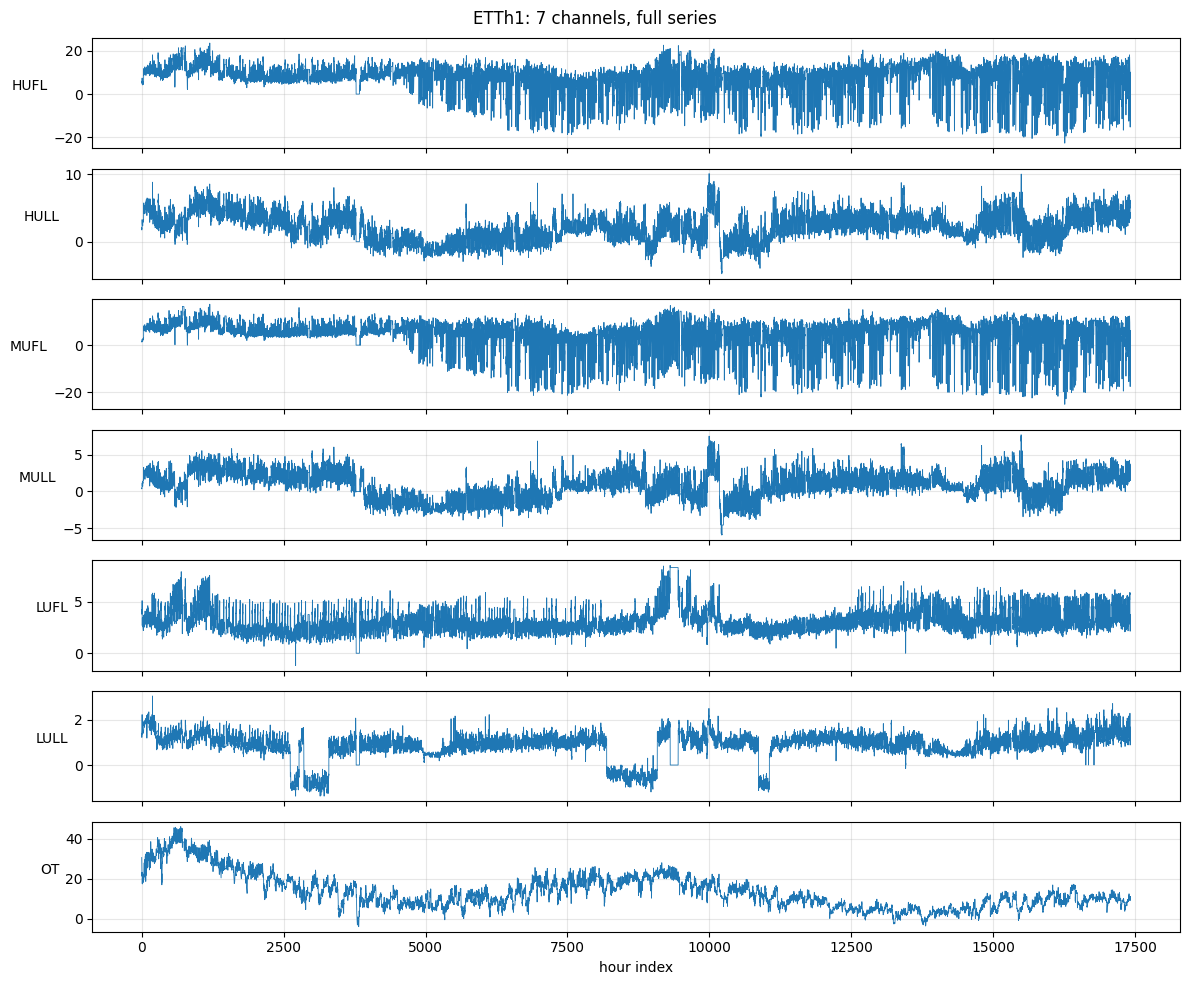

In [6]:
import matplotlib.pyplot as plt

FEATURES = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

fig, axes = plt.subplots(7, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, FEATURES):
    ax.plot(df[col].values, linewidth=0.6)
    ax.set_ylabel(col, rotation=0, ha="right")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("hour index")
fig.suptitle("ETTh1: 7 channels, full series")
fig.tight_layout()
plt.show()


In [7]:
import numpy as np

values = df[FEATURES].to_numpy(dtype=np.float32)  # shape (T, 7)
print("full series shape:", values.shape)

TRAIN_END = 12 * 30 * 24                # 8640
VAL_END   = TRAIN_END + 4 * 30 * 24     # 11520
TEST_END  = VAL_END   + 4 * 30 * 24     # 14400

train = values[:TRAIN_END]
val   = values[TRAIN_END:VAL_END]
test  = values[VAL_END:TEST_END]

print(f"train: {train.shape}  rows [{0:>5}, {TRAIN_END:>5})")
print(f"val:   {val.shape}    rows [{TRAIN_END:>5}, {VAL_END:>5})")
print(f"test:  {test.shape}   rows [{VAL_END:>5}, {TEST_END:>5})")
assert train.shape == (8640, 7)
assert val.shape   == (2880, 7)
assert test.shape  == (2880, 7)

full series shape: (17420, 7)
train: (8640, 7)  rows [    0,  8640)
val:   (2880, 7)    rows [ 8640, 11520)
test:  (2880, 7)   rows [11520, 14400)


In [8]:
mean = train.mean(axis=0, keepdims=True)
std  = train.std (axis=0, keepdims=True) + 1e-8

train_n = (train - mean) / std
val_n   = (val   - mean) / std
test_n  = (test  - mean) / std

np.set_printoptions(precision=3, suppress=True)
print("train mean (per channel):", train_n.mean(0))   # ~ 0
print("train std  (per channel):", train_n.std (0))   # ~ 1
print("val   mean (per channel):", val_n.mean(0))     # NOT 0 — distribution shift
print("test  mean (per channel):", test_n.mean(0))    # NOT 0

train mean (per channel): [ 0.  0. -0.  0.  0.  0.  0.]
train std  (per channel): [1. 1. 1. 1. 1. 1. 1.]
val   mean (per channel): [-0.25  -0.237 -0.298 -0.196  0.583 -0.187 -0.169]
test  mean (per channel): [ 0.032  0.455 -0.057  0.369  0.495  0.287 -1.338]


In [9]:
L, T = 336, 96
n_windows = lambda arr: max(0, len(arr) - L - T + 1)

print(f"train windows (L=336, T=96): {n_windows(train_n)}")
print(f"val   windows:               {n_windows(val_n)}")
print(f"test  windows:               {n_windows(test_n)}")

# Stash for inspection in this session
NORMALIZED = {"train": train_n, "val": val_n, "test": test_n,
              "mean": mean,     "std": std}
{k: v.shape for k, v in NORMALIZED.items()}

train windows (L=336, T=96): 8209
val   windows:               2449
test  windows:               2449


{'train': (8640, 7),
 'val': (2880, 7),
 'test': (2880, 7),
 'mean': (1, 7),
 'std': (1, 7)}